# Trimet Data Project

For our project, we decided to work with Trimet data as it sounded interesting and their developer portal have very good documentation for accessing data.

There were 2 static data GIS (Geospatial Data) and GFTS Static (General Transit Feed Specification).  The GIS basically provides an outline of the Transit map such as stop locations, route boundaries, garage locations and GFTS Static mainly contains text files like `stops.txt` `stop_times.txt` which shows how trimet vehicles are planned to move.

The main interesting we found that had lots of data was GFTS Realtime.  This logs information on Trimet vehicles in realtime giving back information like location using longitude and latitude, whether the vehicle is delayed or early, what its next stop and previous stop is and sometimes even an approximate of how full the vehicle is.

We worked with this api and built a collector in python to collect data on vehicles every minute.  We ran the collector program as much as we can as you cannot have too much data. The data we recieved from the api is formated in json which we converted into a csv.  In this conversion to csv, we only selected specific columns which sounded interesting in order to minimize the size of the csv file.



## Data Processing

Trimet provided documentation for an api called [/vehicles](https://developer.trimet.org/ws_docs/vehicle_locations_ws.shtml) showing information on what data is collected for a vehicle in real time

Example Json data for 1 vehicle.  This is collected every minute.
After going through the documents in trimet, we've infered on what the data means

*Every minute, it logs about 400 vehicles during the day and almost none at night.*

```
  {
    "routeColor": "61A744",            // Color for route
    "expires": 1760993085102,          // Used by trimet to ensure data up to date
    "signMessage": "FX2 To Gresham",   // display message
    "serviceDate": 1760943600000,      // What day it's serviced on
    "loadPercentage": 15,              // Estimated passenger load (0–100%)
    "latitude": 45.503744191408664,    
    "nextStopSeq": 8,                  // The number of next scheduled stop (8th stop of the day)
    "source": "vm",                    // How the data was recorded
    "type": "bus",                     // Vehicle type (bus, rail, etc.)
    "blockID": 248,                    // Groups multiple trips into blocks
    "signMessageLong": "FX2 Division To Gresham", // More description for message
    "lastLocID": 3397,                 // Stop ID of the last stop location
    "nextLocID": 13732,                
    "locationInScheduleDay": 49133,    // what time bus should be at a certain stop
    "routeSubType": "BRT",             // Subtype (e.g., Bus Rapid Transit)
    "newTrip": false,                  // true if new it's new trip, always false in data
    "longitude": -122.66883380836836,  
    "direction": 0,                    // Route direction (0, 1)
    "inCongestion": false,             // True if vehicle is stopped in traffic
    "routeNumber": 2,                  
    "bearing": 46,                     // Vehicle’s compass (0-360)
    "garage": "POWELL",                
    "tripID": "15644087",              
    "delay": -112,                     // measured in seconds, positive means early
    "extraBlockID": null,              
    "messageCode": 100,                // relates to message display
    "lastStopSeq": 7,                  // the last stop number in sequence of sstop
    "vehicleID": 4531,                 
    "time": 1760992845102,             // Timestamp when this was recorded by vehicle
    "offRoute": false                  // True if vehicle is off its scheduled route
  }
```



## Creating DataFrame from csv

In [3]:
import pandas as pd
df = pd.read_csv('../data/vehicle_positions_full_raw.csv')

## Understanding the data

In [4]:
df.head(2)

,bearing,blockID,collection_timestamp,delay,direction,expires,extraBlockID,garage,inCongestion,lastLocID,...,routeNumber,routeSubType,serviceDate,signMessage,signMessageLong,source,time,tripID,type,vehicleID
0,200.0,243,1760817789,-1132,0,1760818026912,NaN,POWELL,False,7642.0,...,2,BRT,1760770800000,FX2 To Gresham,FX2 Division To Gresham,vm,1760817786912,15643905,bus,4530
1,269.0,248,1760817789,-499,1,1760818022926,NaN,POWELL,False,14241.0,...,2,BRT,1760770800000,FX2 To Portland,FX2 Division To Portland,vm,1760817782926,15644364,bus,4528


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 727199 entries, 0 to 727198
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   bearing                727184 non-null  float64
 1   blockID                727199 non-null  int64  
 2   collection_timestamp   727199 non-null  int64  
 3   delay                  727199 non-null  int64  
 4   direction              727199 non-null  int64  
 5   expires                727199 non-null  int64  
 6   extraBlockID           1611 non-null    float64
 7   garage                 725588 non-null  object 
 8   inCongestion           562449 non-null  object 
 9   lastLocID              601971 non-null  float64
 10  lastStopSeq            601971 non-null  float64
 11  latitude               727199 non-null  float64
 12  loadPercentage         491051 non-null  float64
 13  locationInScheduleDay  727199 non-null  int64  
 14  longitude              727199 non-nu

### Setting up data for analysis

#### 1. Clean up with Date and Time

In [6]:
df_clean = df
df_clean['collection_timestamp'] = pd.to_datetime(df_clean['collection_timestamp'], unit='s', errors='coerce')
df_clean['serviceDate'] = pd.to_datetime(df_clean['serviceDate'], unit='ms', errors='coerce')
df_clean['time'] = pd.to_datetime(df_clean['time'], unit='ms', errors='coerce')
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 727199 entries, 0 to 727198
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   bearing                727184 non-null  float64       
 1   blockID                727199 non-null  int64         
 2   collection_timestamp   727199 non-null  datetime64[ns]
 3   delay                  727199 non-null  int64         
 4   direction              727199 non-null  int64         
 5   expires                727199 non-null  int64         
 6   extraBlockID           1611 non-null    float64       
 7   garage                 725588 non-null  object        
 8   inCongestion           562449 non-null  object        
 9   lastLocID              601971 non-null  float64       
 10  lastStopSeq            601971 non-null  float64       
 11  latitude               727199 non-null  float64       
 12  loadPercentage         491051 non-null  floa

#### 2. Let's extract the day of the week and hour to make it easier to analyze

In [7]:
df['hour'] = df['collection_timestamp'].dt.hour
df['day'] = df['collection_timestamp'].dt.day_name()

### Non obvious columns

#### 3. Investigate columns to see if information is relevant

Some columns are not straightforward and will need more research to get better understanding.  Potentially could be removed from analyzing if not significant or redundant

#### routeSubType

In [8]:
# Check what RouteSubtype column is:
df['routeSubType'].unique()

array(['BRT', 'Bus', 'Light Rail', 'Shuttle'], dtype=object)

This shows that `routeSubType` gives more specification to vehicle info.  A BRT is "Bus Rapid Transit" and a "Bus" is the smaller old buses both are categorized as `bus` for the `type` column.

#### offRoute

Perhaps we can see if vehicles ever go off route

In [9]:
df['offRoute'].value_counts()

offRoute
False    722640
True       4559
Name: count, dtype: int64

A small portion goes off route which will be interesting to anlyze later on.

#### Extra Block ID


In [10]:
extra_block_rows = df[df['extraBlockID'].notna()]

# count where extraBlockID = blockID
same = (df['extraBlockID'] == df['blockID']).sum()
# count how many extrablocks there are
diff = df['extraBlockID'].notna().sum()

print(f"Extrablock id same as block id: {same}")
print(f"Total extrablock ids : {diff}")



Extrablock id same as block id: 1611
Total extrablock ids : 1611


From the above code, we can see extrablockid and blockid is always the same.  So it might just be redundant information.

Let's look into how often extraBlockID appears

In [11]:
df['extraBlockID'].value_counts()

extraBlockID
767.0    413
734.0    259
702.0    225
701.0    213
768.0    200
736.0    147
769.0     76
737.0     50
770.0     28
Name: count, dtype: int64

The blockID starting with 700 seems to be the only one recording extrablock id which might be interesting case to study later.

#### New Trip is always false

In [12]:

print(df['newTrip'].value_counts())
print(df['offRoute'].value_counts())

newTrip
False    727199
Name: count, dtype: int64
offRoute
False    722640
True       4559
Name: count, dtype: int64


newTrip is always False, but sometimes buses go offRoute.

After investigating, we are choosing to drop some columns that might not be used

- expires: used internally to ensure data up to date
- newTrip: likely deprecated since it's always false.  Suppose to show when a bus starts a new trip but maybe our 1 minute interval does not catch it when it was sent.
- serviceDate: redundant, already have that with other columns
- routeColor - redundant, route number should be sufficient to know color


In [13]:
df = df.drop(columns=['expires', 'newTrip', 'serviceDate', 'routeColor'])

### Checking for outliers

In [14]:
df.describe()

,bearing,blockID,collection_timestamp,delay,direction,extraBlockID,lastLocID,lastStopSeq,latitude,loadPercentage,locationInScheduleDay,longitude,messageCode,nextLocID,nextStopSeq,routeNumber,time,tripID,vehicleID,hour
count,727184.000000,727199.000000,727199,727199.000000,727199.000000,1611.000000,601971.000000,601971.000000,727199.000000,491051.000000,727199.000000,727199.000000,727199.000000,727199.000000,727199.000000,727199.000000,727199,7.271990e+05,727199.000000,727199.000000
mean,175.633082,5168.212412,2025-10-19 19:40:40.238534144,-128.287474,0.498400,740.400993,7563.460567,29.581302,45.507922,10.889773,51229.364086,-122.664693,613.279281,7899.231099,24.523740,64.997089,2025-10-19 19:40:25.021113344,1.562486e+07,2905.597924,13.061586
min,0.000000,134.000000,2025-10-18 20:03:09,-8595.000000,0.000000,701.000000,2.000000,1.000000,45.284999,0.000000,11784.000000,-123.115567,13.000000,2.000000,1.000000,1.000000,2025-10-18 19:57:06.241000,9.007170e+05,103.000000,0.000000
25%,90.000000,1902.000000,2025-10-19 04:56:48,-157.000000,0.000000,702.000000,4439.000000,11.000000,45.490587,1.000000,35950.000000,-122.715628,316.000000,4651.000000,3.000000,19.000000,2025-10-19 04:55:46.507000064,1.565053e+07,3024.000000,4.000000
50%,180.000000,5473.000000,2025-10-19 20:33:21,-30.000000,0.000000,736.000000,8045.000000,24.000000,45.517125,7.000000,51277.000000,-122.662312,637.000000,8345.000000,17.000000,57.000000,2025-10-19 20:33:20.299000064,1.565755e+07,3420.000000,15.000000
75%,270.000000,8743.000000,2025-10-20 05:20:31,0.000000,1.000000,767.000000,10028.000000,42.000000,45.530573,16.000000,65024.000000,-122.578744,863.000000,10611.000000,38.000000,88.000000,2025-10-20 05:19:29.446000128,1.566456e+07,3935.000000,20.000000
max,359.000000,9767.000000,2025-10-20 18:54:17,8893.000000,1.000000,770.000000,14661.000000,133.000000,45.639116,146.000000,97800.000000,-122.330200,1094.000000,14661.000000,134.000000,293.000000,2025-10-20 18:54:16.908000,1.567294e+07,4531.000000,23.000000
std,102.343308,3249.810505,NaN,375.320404,0.499998,27.388769,4042.059391,24.164961,0.048849,12.866280,18010.849297,0.127264,324.258516,4132.484296,24.947662,60.402103,NaN,6.911754e+05,1439.332417,7.768290


Some obvious concerning outliers:
* ~9000 seconds, over 2 hours early vehicles
* 146 load percentage

Let's investigate


### Look Into delay column

In [39]:
# Check for bus over 1 hour late or early
hour_early = df[df['delay'] > 3600]
hour_early.head(5)


,bearing,blockID,collection_timestamp,delay,direction,extraBlockID,garage,inCongestion,lastLocID,lastStopSeq,...,routeSubType,signMessage,signMessageLong,source,time,tripID,type,vehicleID,hour,day
43387,294.0,9024,2025-10-18 21:53:08,6897,1,NaN,ELMO,NaN,9832.0,37.0,...,Light Rail,Blue Line to Hillsboro,MAX Blue Line to Hillsboro,tab,2025-10-18 21:53:03.907,15668041,rail,228,21,Saturday
43388,294.0,9024,2025-10-18 21:53:08,6897,1,NaN,ELMO,NaN,9832.0,37.0,...,Light Rail,Blue Line to Hillsboro,MAX Blue Line to Hillsboro,tab,2025-10-18 21:53:03.907,15668041,rail,120,21,Saturday
43775,294.0,9024,2025-10-18 21:54:08,6924,1,NaN,ELMO,NaN,9832.0,37.0,...,Light Rail,Blue Line to Hillsboro,MAX Blue Line to Hillsboro,tab,2025-10-18 21:54:04.857,15668041,rail,228,21,Saturday
43776,294.0,9024,2025-10-18 21:54:08,6924,1,NaN,ELMO,NaN,9832.0,37.0,...,Light Rail,Blue Line to Hillsboro,MAX Blue Line to Hillsboro,tab,2025-10-18 21:54:04.857,15668041,rail,120,21,Saturday
44161,285.0,9024,2025-10-18 21:55:08,6925,1,NaN,ELMO,NaN,9832.0,37.0,...,Light Rail,Blue Line to Hillsboro,MAX Blue Line to Hillsboro,tab,2025-10-18 21:54:55.295,15668041,rail,228,21,Saturday


In [16]:
hour_late = df[df['delay'] < -3600]
hour_late

,bearing,blockID,collection_timestamp,delay,direction,extraBlockID,garage,inCongestion,lastLocID,lastStopSeq,...,routeSubType,signMessage,signMessageLong,source,time,tripID,type,vehicleID,hour,day
38,1.0,605,2025-10-18 20:03:09,-3705,0,NaN,CENTER,False,5918.0,37.0,...,Bus,6 To Jantzen Beach,6 M L King JR to Jantzen Beach Via Schmeer Rd,vm,2025-10-18 20:03:03.879,15645429,bus,4212,20,Saturday
98,174.0,3034,2025-10-18 20:03:09,-5520,0,NaN,POWELL,False,NaN,NaN,...,Bus,30 To Estacada,30 Estacada,vm,2025-10-18 20:03:00.796,15652655,bus,3934,20,Saturday
445,70.0,605,2025-10-18 20:05:43,-3700,0,NaN,CENTER,False,5932.0,38.0,...,Bus,6 To Jantzen Beach,6 M L King JR to Jantzen Beach Via Schmeer Rd,vm,2025-10-18 20:05:40.733,15645429,bus,4212,20,Saturday
505,174.0,3034,2025-10-18 20:05:43,-5679,0,NaN,POWELL,False,NaN,NaN,...,Bus,30 To Estacada,30 Estacada,vm,2025-10-18 20:05:39.747,15652655,bus,3934,20,Saturday
522,194.0,1434,2025-10-18 20:05:43,-3652,0,NaN,POWELL,False,7655.0,19.0,...,Bus,14 To SE Foster & 94th,14 Foster Rd to SE 94th Ave,vm,2025-10-18 20:05:40.748,15648455,bus,3754,20,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195117,344.0,9044,2025-10-19 06:12:07,-8595,1,NaN,ELMO,NaN,NaN,NaN,...,Light Rail,Red Line to Hillsboro Airport,MAX Red Line to Hills Airport/Fairgrounds/City...,tab,2025-10-19 06:03:15.284,15665642,rail,615,6,Sunday
195118,344.0,9044,2025-10-19 06:12:07,-8595,1,NaN,ELMO,NaN,NaN,NaN,...,Light Rail,Red Line to Hillsboro Airport,MAX Red Line to Hills Airport/Fairgrounds/City...,tab,2025-10-19 06:03:15.284,15665642,rail,606,6,Sunday
195272,344.0,9044,2025-10-19 06:13:07,-8595,1,NaN,ELMO,NaN,NaN,NaN,...,Light Rail,Red Line to Hillsboro Airport,MAX Red Line to Hills Airport/Fairgrounds/City...,tab,2025-10-19 06:03:15.284,15665642,rail,615,6,Sunday
195273,344.0,9044,2025-10-19 06:13:07,-8595,1,NaN,ELMO,NaN,NaN,NaN,...,Light Rail,Red Line to Hillsboro Airport,MAX Red Line to Hills Airport/Fairgrounds/City...,tab,2025-10-19 06:03:15.284,15665642,rail,606,6,Sunday


There were 222 rows of recorded data showing that vehicles were over 1 hour early and 334 records for late

In [17]:
hour_early['signMessageLong'].value_counts()

signMessageLong
ADA Shuttle to 60th AVE                      82
MAX  Blue Line to Hillsboro                  72
MAX  Blue Line to Gresham                    38
MAX Red Line to Hills Airport/Fairgrounds    26
72  82nd Ave to Clackamas Town Center         3
19  Glisan to Gateway TC                      1
Name: count, dtype: int64

In [18]:
hour_late['signMessageLong'].value_counts()

signMessageLong
MAX Red Line to Hills Airport/Fairgrounds/City Center    108
MAX  Blue Line to Gresham                                 38
30  Clackamas Town Center                                 37
FX2 Division To Gresham                                   36
17  Broadway to NE Saratoga & 27th                        34
30  Estacada                                              30
6 M L King JR to Jantzen Beach via Hayden Meadows Dr      28
6  To Jantzen Beach                                       12
14 Foster Rd to SE 94th Ave                                5
6 M L King JR to Jantzen Beach Via Schmeer Rd              3
6  To SW 18th Ave - Goose Hollow MAX Station               2
96  To SW 10th & Jefferson                                 1
Name: count, dtype: int64

In [19]:
hour_early['routeNumber'].value_counts()

routeNumber
100    110
98      82
90      26
72       3
19       1
Name: count, dtype: int64

In [20]:
hour_late['routeNumber'].value_counts()

routeNumber
90     108
30      67
6       45
100     38
2       36
17      34
14       5
96       1
Name: count, dtype: int64

In [37]:
route100 = hour_early[hour_early['routeNumber'] == 100]
route100.head(5)

,bearing,blockID,collection_timestamp,delay,direction,extraBlockID,garage,inCongestion,lastLocID,lastStopSeq,...,routeSubType,signMessage,signMessageLong,source,time,tripID,type,vehicleID,hour,day
43387,294.0,9024,2025-10-18 21:53:08,6897,1,NaN,ELMO,NaN,9832.0,37.0,...,Light Rail,Blue Line to Hillsboro,MAX Blue Line to Hillsboro,tab,2025-10-18 21:53:03.907,15668041,rail,228,21,Saturday
43388,294.0,9024,2025-10-18 21:53:08,6897,1,NaN,ELMO,NaN,9832.0,37.0,...,Light Rail,Blue Line to Hillsboro,MAX Blue Line to Hillsboro,tab,2025-10-18 21:53:03.907,15668041,rail,120,21,Saturday
43775,294.0,9024,2025-10-18 21:54:08,6924,1,NaN,ELMO,NaN,9832.0,37.0,...,Light Rail,Blue Line to Hillsboro,MAX Blue Line to Hillsboro,tab,2025-10-18 21:54:04.857,15668041,rail,228,21,Saturday
43776,294.0,9024,2025-10-18 21:54:08,6924,1,NaN,ELMO,NaN,9832.0,37.0,...,Light Rail,Blue Line to Hillsboro,MAX Blue Line to Hillsboro,tab,2025-10-18 21:54:04.857,15668041,rail,120,21,Saturday
44161,285.0,9024,2025-10-18 21:55:08,6925,1,NaN,ELMO,NaN,9832.0,37.0,...,Light Rail,Blue Line to Hillsboro,MAX Blue Line to Hillsboro,tab,2025-10-18 21:54:55.295,15668041,rail,228,21,Saturday


The conclusion as of now is that a lot of rail are unusually early or late.  Also the case for some buses like the bus to Clackamas TC.  This will need to be investigated more throughly to understand why this is the cas.

### Over 100 Load Percentage

Load percentage should be 0-100 as a fraction.  Let's investigate why there is over 100 for the max value.

In [36]:
bad_load = df[df['loadPercentage'] > 100]
bad_load.head(5)

,bearing,blockID,collection_timestamp,delay,direction,extraBlockID,garage,inCongestion,lastLocID,lastStopSeq,...,routeSubType,signMessage,signMessageLong,source,time,tripID,type,vehicleID,hour,day
36,291.0,1505,2025-10-18 20:03:09,-927,0,NaN,CENTER,False,7216.0,43.0,...,Bus,15 To NW Yeon,15 Belmont/NW 23rd to NW Yeon via City Center,vm,2025-10-18 20:03:02.926,15649138,bus,4217,20,Saturday
443,270.0,1505,2025-10-18 20:05:43,-979,0,NaN,CENTER,False,4019.0,46.0,...,Bus,15 To NW Yeon,15 Belmont/NW 23rd to NW Yeon via City Center,vm,2025-10-18 20:05:36.820,15649138,bus,4217,20,Saturday
849,270.0,1505,2025-10-18 20:06:43,-998,0,NaN,CENTER,False,4016.0,47.0,...,Bus,15 To NW Yeon,15 Belmont/NW 23rd to NW Yeon via City Center,vm,2025-10-18 20:06:38.263,15649138,bus,4217,20,Saturday
1254,270.0,1505,2025-10-18 20:07:43,-1094,0,NaN,CENTER,False,4019.0,46.0,...,Bus,15 To NW Yeon,15 Belmont/NW 23rd to NW Yeon via City Center,vm,2025-10-18 20:07:35.652,15649138,bus,4217,20,Saturday
1660,270.0,1505,2025-10-18 20:08:43,-1070,0,NaN,CENTER,False,4014.0,48.0,...,Bus,15 To NW Yeon,15 Belmont/NW 23rd to NW Yeon via City Center,vm,2025-10-18 20:08:36.499,15649138,bus,4217,20,Saturday


In [23]:
time_info = ['collection_timestamp', 'delay', 'time', 'hour', 'day']
# select info to focus on for load
load_perc_info = time_info.copy() + ['routeSubType', 'loadPercentage', 'vehicleID', 'signMessage', 'inCongestion']
bad_load = bad_load[load_perc_info]

Check loadpercentage relationship with vehicleID

In [24]:
bad_load['vehicleID'].value_counts()

vehicleID
3514    99
3543    56
3711    35
3570    26
4405    26
3546    24
3504    22
3322    18
4305    18
3537    16
3716    14
4055    11
3007    11
3574    10
3708    10
3234    10
3126    10
3614     9
4217     7
3749     7
3169     7
3230     7
3950     7
3909     7
3953     6
3170     6
3217     6
4018     6
3124     6
3905     5
3122     4
3108     4
3903     4
Name: count, dtype: int64

In [25]:
bus_3514 = df[
    (df['vehicleID'] == 3514) &
    (df['loadPercentage'] > 70) 
].sort_values('time')
bus_3514 = bus_3514[load_perc_info].copy()
bus_3514

,collection_timestamp,delay,time,hour,day,routeSubType,loadPercentage,vehicleID,signMessage,inCongestion
36957,2025-10-18 21:37:04,-445,2025-10-18 21:37:02.082,21,Saturday,Bus,103.0,3514,70 To Milwaukie,False
37347,2025-10-18 21:38:04,-497,2025-10-18 21:38:01.402,21,Saturday,Bus,103.0,3514,70 To Milwaukie,False
37736,2025-10-18 21:39:04,-493,2025-10-18 21:39:01.775,21,Saturday,Bus,103.0,3514,70 To Milwaukie,False
38130,2025-10-18 21:40:05,-498,2025-10-18 21:40:01.044,21,Saturday,Bus,100.0,3514,70 To Milwaukie,False
38524,2025-10-18 21:41:05,-464,2025-10-18 21:41:00.473,21,Saturday,Bus,100.0,3514,70 To Milwaukie,False
...,...,...,...,...,...,...,...,...,...,...
501239,2025-10-20 02:21:48,-175,2025-10-20 02:21:42.756,2,Monday,Bus,76.0,3514,72 Swan Island,False
501558,2025-10-20 02:22:48,-172,2025-10-20 02:22:46.182,2,Monday,Bus,76.0,3514,72 Swan Island,False
501876,2025-10-20 02:23:48,-188,2025-10-20 02:23:46.660,2,Monday,Bus,76.0,3514,72 Swan Island,False
502193,2025-10-20 02:24:49,-124,2025-10-20 02:24:43.036,2,Monday,Bus,76.0,3514,72 Swan Island,False


After looking at the bus 3514, it seems that load percentage can potentially malfunction.  Perhaps it calculates using infarred to see how many people are on board and how many people off board but it could be possible that people getting off were no longer tracked.  Without knowing how it was collected, it's hard to conclude why there are odd numbers.

Another possibility could also be that after the bus stops, load_percentage no longer gets updated and the last value is what is shown by the API.  This is supported by the fact that the weird data pops up around the start and end of the day and not during the middle of the day.

In [26]:
bus_3514['hour'].value_counts()

hour
1     83
0     66
23    60
2     47
21    23
22    11
Name: count, dtype: int64

In [27]:
df_clean['time_of_day'] = df_clean['collection_timestamp'].dt.time
df_clean['hour_decimal'] = (
    df_clean['collection_timestamp'].dt.hour + 
    df_clean['collection_timestamp'].dt.minute / 60
)

df_clean['delay_minutes'] = df_clean['delay'] / 60



# Data Visualization

In [28]:
import matplotlib.pyplot as plt


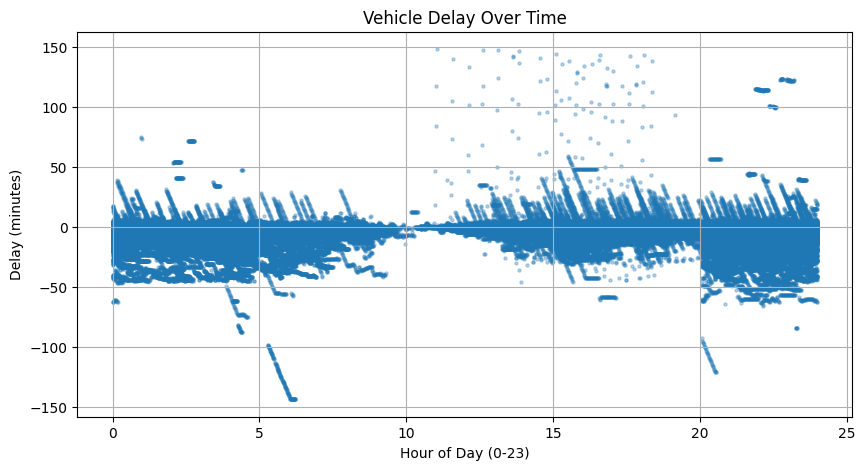

In [29]:

plt.figure(figsize = (10,5))
plt.scatter(df_clean['hour_decimal'], df_clean['delay_minutes'], s=5, alpha = 0.3)
plt.title('Vehicle Delay Over Time')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Delay (minutes)')
plt.grid(True)
plt.show()

Text(0, 0.5, 'Delay (minutes)')

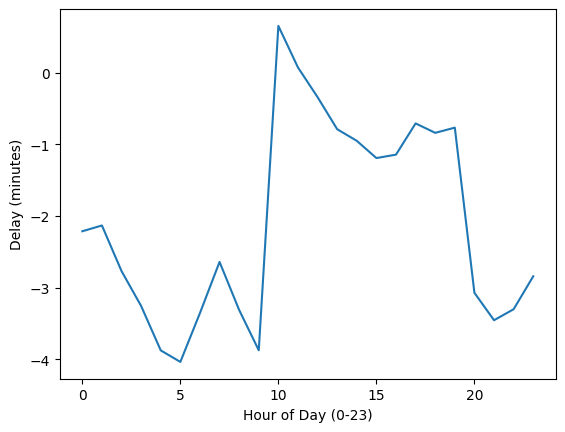

In [30]:
avg_delay = df_clean.groupby('hour')['delay_minutes'].mean()
plt.plot(avg_delay.index, avg_delay.values)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Delay (minutes)')


Text(0.5, 1.0, 'Distribution of Bus Delays')

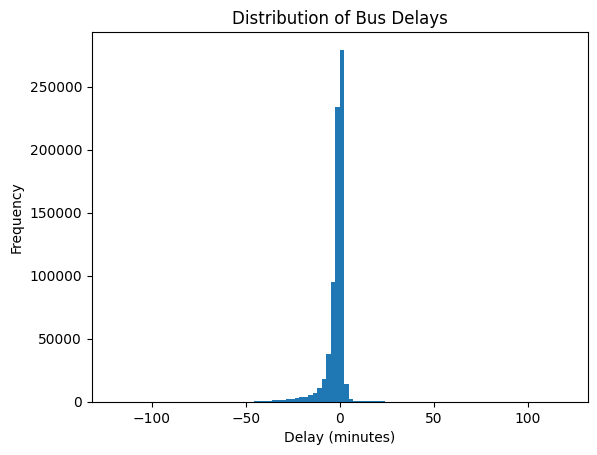

In [31]:
df_clean['delay_minutes'].plot(kind='hist', bins=100, range=(-120, 120))
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Bus Delays")


From the histogram, we can see that the distribution of data is mainly near 0 where buses are reporting postive or negative delay.  There are only some extreme reporting of data going + or - 30 minutes.  So it is probably safe to discard these bad datas as it won't actually have much impact in the end.

In [64]:
cutoff_delay = 30
outliers = df_clean[(df_clean['delay_minutes'] < -cutoff_delay) | (df_clean['delay_minutes'] > cutoff_delay)]
print(outliers['delay_minutes'].describe())
percent_outliers = len(outliers) / len(df_clean) * 100
print(f'{percent_outliers:.2f} % of vehicles is {cutoff_delay} early or late')


count    7151.000000
mean      -30.952240
std        34.872904
min      -143.250000
25%       -42.050000
50%       -36.150000
75%       -32.366667
max       148.216667
Name: delay_minutes, dtype: float64
0.98 % of vehicles is 30 early or late


After checking the outliers, we can see that only about 7100 rows out of 700,000 have delays over 30 minutes and the standard deviation is very high meaning there is a lot of spread and buses are extreamely early or late.

In [ ]:

df_filtered = df_clean[(df_clean['delay_minutes'] >= -cutoff_delay) & (df_clean['delay_minutes'] <= cutoff_delay)]

print("Before cleaning delays")
print(df_clean['delay_minutes'].describe())
print("After cleaning delays")
print(df_filtered['delay_minutes'].describe())

count    727199.000000
mean         -2.138125
std           6.255340
min        -143.250000
25%          -2.616667
50%          -0.500000
75%           0.000000
max         148.216667
Name: delay_minutes, dtype: float64
count    720048.000000
mean         -1.851963
std           4.372019
min         -30.000000
25%          -2.533333
50%          -0.466667
75%           0.000000
max          30.000000
Name: delay_minutes, dtype: float64
